# Online approximation for rolling Approximate Entropy

Exact rolling ApEn is expensive. For every window we compare many embedded vectors against
many other embedded vectors. The cost grows roughly quadratically with the number of patterns
inside the window.

In high-throughput streams, that is often too slow. This notebook builds a practical
approximation based on **Monte Carlo sampling of reference and comparison patterns**.

It is not an exact replacement. It is a throughput-oriented approximation that trades some
accuracy for speed.

In [1]:
from __future__ import annotations

from typing import Iterable, Sequence
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams["figure.figsize"] = (10, 4)


def to_1d_float_array(x: Sequence[float] | np.ndarray, *, name: str = "x") -> np.ndarray:
    """Validate and convert input to a 1D float NumPy array."""
    arr = np.asarray(x, dtype=float)
    if arr.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, got shape={arr.shape}.")
    if arr.size == 0:
        raise ValueError(f"{name} must contain at least one value.")
    if not np.isfinite(arr).all():
        raise ValueError(f"{name} contains NaN or infinite values.")
    return arr


def embed(series: Sequence[float] | np.ndarray, m: int) -> np.ndarray:
    """Return the delay-embedding matrix with lag 1 and dimension m."""
    x = to_1d_float_array(series)
    if not isinstance(m, int) or m < 1:
        raise ValueError("m must be a positive integer.")
    n = x.size
    if n <= m:
        raise ValueError(f"Need len(series) > m, got n={n}, m={m}.")
    return np.lib.stride_tricks.sliding_window_view(x, m)


def phi(series: Sequence[float] | np.ndarray, m: int, r: float) -> float:
    """Compute the ApEn phi_m quantity using the Chebyshev distance."""
    x = to_1d_float_array(series)
    if not np.isfinite(r) or r <= 0:
        raise ValueError("r must be a positive finite number.")

    patterns = embed(x, m)
    # Pairwise Chebyshev distance between all embedded vectors.
    distances = np.max(np.abs(patterns[:, None, :] - patterns[None, :, :]), axis=2)
    c_i = np.mean(distances <= r, axis=1)
    c_i = np.clip(c_i, 1e-12, None)
    return float(np.mean(np.log(c_i)))


def approximate_entropy(series: Sequence[float] | np.ndarray, m: int = 2, r: float | None = None) -> float:
    """Approximate Entropy (ApEn).

    Parameters
    ----------
    series:
        Input time series.
    m:
        Embedding dimension.
    r:
        Tolerance. If omitted, uses 0.2 * standard deviation of the series.
    """
    x = to_1d_float_array(series)
    if r is None:
        std = float(np.std(x, ddof=0))
        r = 0.2 * std if std > 0 else 0.2
    return phi(x, m, r) - phi(x, m + 1, r)


def sample_entropy(series: Sequence[float] | np.ndarray, m: int = 2, r: float | None = None) -> float:
    """Sample Entropy (SampEn) with Chebyshev distance."""
    x = to_1d_float_array(series)
    if r is None:
        std = float(np.std(x, ddof=0))
        r = 0.2 * std if std > 0 else 0.2
    if not np.isfinite(r) or r <= 0:
        raise ValueError("r must be a positive finite number.")

    def _count_matches(patterns: np.ndarray) -> float:
        distances = np.max(np.abs(patterns[:, None, :] - patterns[None, :, :]), axis=2)
        matches = (distances <= r).astype(float)
        np.fill_diagonal(matches, 0.0)
        return float(matches.sum())

    patterns_m = embed(x, m)
    patterns_m1 = embed(x, m + 1)

    b = _count_matches(patterns_m)
    a = _count_matches(patterns_m1)

    if a == 0.0 or b == 0.0:
        return float("inf")
    return float(-np.log(a / b))


def zscore(series: Sequence[float] | np.ndarray) -> np.ndarray:
    """Standardize a numeric series."""
    x = to_1d_float_array(series)
    std = float(np.std(x, ddof=0))
    if std == 0.0:
        return np.zeros_like(x)
    return (x - np.mean(x)) / std

In [2]:
from collections import deque
from dataclasses import dataclass
from time import perf_counter


def approximate_entropy_from_patterns(patterns_m: np.ndarray, patterns_m1: np.ndarray, r: float) -> float:
    """Compute ApEn given already embedded patterns for m and m+1."""
    dist_m = np.max(np.abs(patterns_m[:, None, :] - patterns_m[None, :, :]), axis=2)
    c_m = np.mean(dist_m <= r, axis=1)
    c_m = np.clip(c_m, 1e-12, None)

    dist_m1 = np.max(np.abs(patterns_m1[:, None, :] - patterns_m1[None, :, :]), axis=2)
    c_m1 = np.mean(dist_m1 <= r, axis=1)
    c_m1 = np.clip(c_m1, 1e-12, None)

    return float(np.mean(np.log(c_m)) - np.mean(np.log(c_m1)))


def approximate_entropy_mc(
    series: Sequence[float] | np.ndarray,
    *,
    m: int = 2,
    r: float | None = None,
    n_ref: int = 30,
    n_cmp: int = 50,
    seed: int = 0,
) -> float:
    """Monte Carlo approximation of ApEn.

    We sample:
    - a subset of reference vectors,
    - a subset of comparison vectors.

    The estimate is biased in finite samples, but can be much faster than the exact version.
    """
    x = to_1d_float_array(series)
    if r is None:
        std = float(np.std(x, ddof=0))
        r = 0.2 * std if std > 0 else 0.2

    rng = np.random.default_rng(seed)

    patterns_m = embed(x, m)
    patterns_m1 = embed(x, m + 1)

    def _estimate(patterns: np.ndarray) -> float:
        n = patterns.shape[0]
        ref_idx = rng.choice(n, size=min(n_ref, n), replace=False)
        cmp_idx = rng.choice(n, size=min(n_cmp, n), replace=False)
        refs = patterns[ref_idx]
        cmps = patterns[cmp_idx]
        dist = np.max(np.abs(refs[:, None, :] - cmps[None, :, :]), axis=2)
        c_hat = np.mean(dist <= r, axis=1)
        c_hat = np.clip(c_hat, 1e-12, None)
        return float(np.mean(np.log(c_hat)))

    return _estimate(patterns_m) - _estimate(patterns_m1)


@dataclass
class StreamingMonteCarloApEn:
    window: int
    m: int = 2
    r_factor: float = 0.2
    n_ref: int = 30
    n_cmp: int = 50
    seed: int = 0

    def __post_init__(self) -> None:
        if not isinstance(self.window, int) or self.window <= self.m + 1:
            raise ValueError("window must be an integer larger than m + 1.")
        self.buffer: deque[float] = deque(maxlen=self.window)
        self._counter = 0

    def update(self, value: float) -> float:
        """Push a new observation and return approximate rolling ApEn when available."""
        self.buffer.append(float(value))
        self._counter += 1

        if len(self.buffer) < self.window:
            return float("nan")

        arr = np.asarray(self.buffer, dtype=float)
        std = float(np.std(arr, ddof=0))
        r = self.r_factor * std if std > 0 else self.r_factor
        return approximate_entropy_mc(
            arr,
            m=self.m,
            r=r,
            n_ref=self.n_ref,
            n_cmp=self.n_cmp,
            seed=self.seed + self._counter,
        )


def exact_rolling_apen(
    series: Sequence[float] | np.ndarray,
    *,
    window: int,
    m: int = 2,
) -> pd.Series:
    """Exact rolling ApEn with right-edge indexing."""
    x = to_1d_float_array(series)
    values: list[float] = [np.nan] * (window - 1)
    for end in range(window, x.size + 1):
        segment = x[end - window : end]
        values.append(approximate_entropy(segment, m=m))
    return pd.Series(values)

## Synthetic streaming series with structural changes

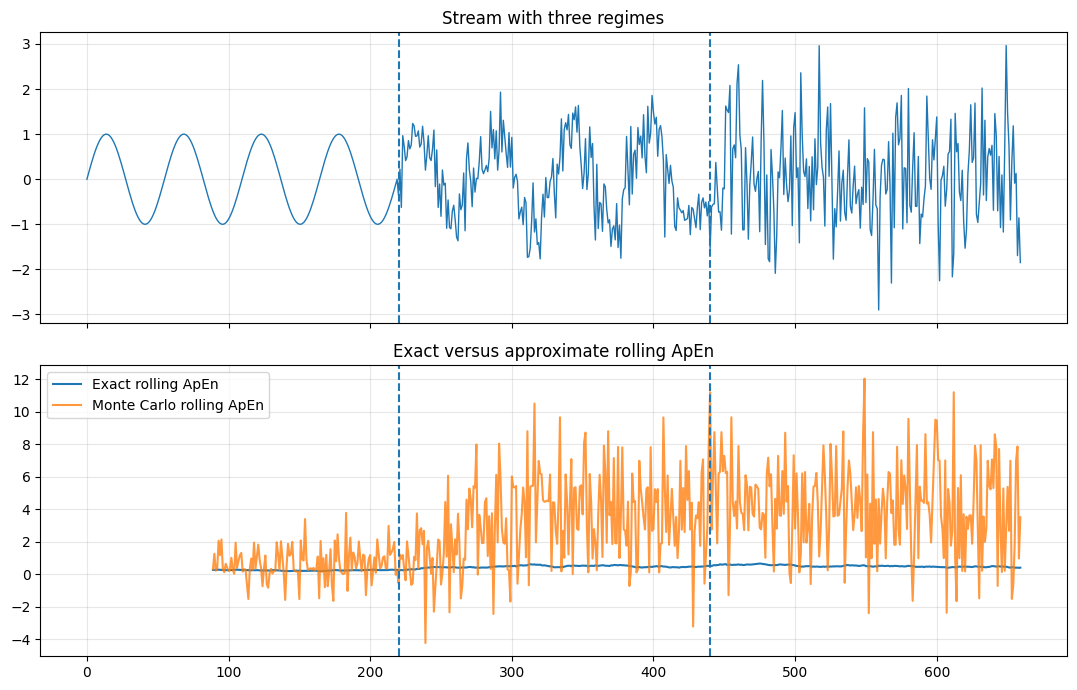

In [3]:
rng = np.random.default_rng(2026)

stream = np.concatenate(
    [
        np.sin(np.linspace(0.0, 8.0 * np.pi, 220)),
        np.sin(np.linspace(0.0, 8.0 * np.pi, 220)) + 0.45 * rng.normal(size=220),
        rng.normal(size=220),
    ]
)

window = 90

streaming_estimator = StreamingMonteCarloApEn(
    window=window,
    m=2,
    r_factor=0.2,
    n_ref=28,
    n_cmp=45,
    seed=7,
)

rolling_apen_mc = pd.Series([streaming_estimator.update(v) for v in stream])
rolling_apen_exact = exact_rolling_apen(stream, window=window, m=2)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(stream, linewidth=1.0)
axes[0].axvline(220, linestyle="--")
axes[0].axvline(440, linestyle="--")
axes[0].set_title("Stream with three regimes")
axes[0].grid(alpha=0.3)

axes[1].plot(rolling_apen_exact, label="Exact rolling ApEn")
axes[1].plot(rolling_apen_mc, label="Monte Carlo rolling ApEn", alpha=0.8)
axes[1].axvline(220, linestyle="--")
axes[1].axvline(440, linestyle="--")
axes[1].set_title("Exact versus approximate rolling ApEn")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()

In [4]:
comparison = pd.DataFrame(
    {
        "exact": rolling_apen_exact,
        "approximate_mc": rolling_apen_mc,
    }
).dropna()

comparison["absolute_error"] = (comparison["exact"] - comparison["approximate_mc"]).abs()
comparison.describe().T

,count,mean,std,min,25%,50%,75%,max
exact,571.0,0.433541,0.119994,0.198480,0.305449,0.466218,0.515916,0.661044
approximate_mc,571.0,3.016750,2.765235,-4.227867,0.952564,2.719385,5.238340,12.035956
absolute_error,571.0,2.877206,2.387989,0.008171,0.859848,2.251822,4.745986,11.485403


0.5278124819064235

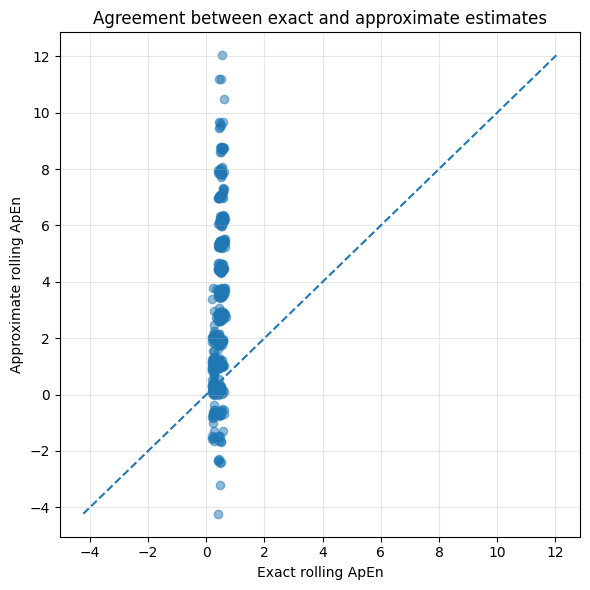

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(comparison["exact"], comparison["approximate_mc"], alpha=0.5)
lims = [
    min(comparison["exact"].min(), comparison["approximate_mc"].min()),
    max(comparison["exact"].max(), comparison["approximate_mc"].max()),
]
ax.plot(lims, lims, linestyle="--")
ax.set_xlabel("Exact rolling ApEn")
ax.set_ylabel("Approximate rolling ApEn")
ax.set_title("Agreement between exact and approximate estimates")
ax.grid(alpha=0.3)
plt.tight_layout()

correlation = float(comparison["exact"].corr(comparison["approximate_mc"]))
correlation

## Benchmark

The timing below is a simple local benchmark. It is not a universal performance claim.
The numbers depend on window size, sample count, machine, and implementation details.

In [6]:
benchmark_signal = np.concatenate(
    [
        np.sin(np.linspace(0.0, 12.0 * np.pi, 300)),
        rng.normal(size=300),
    ]
)

start = perf_counter()
exact_values = exact_rolling_apen(benchmark_signal, window=80, m=2)
exact_time = perf_counter() - start

start = perf_counter()
estimator = StreamingMonteCarloApEn(window=80, m=2, r_factor=0.2, n_ref=24, n_cmp=36, seed=11)
approx_values = pd.Series([estimator.update(v) for v in benchmark_signal])
approx_time = perf_counter() - start

pd.DataFrame(
    {
        "method": ["exact", "approximate_mc"],
        "seconds": [exact_time, approx_time],
        "relative_to_exact": [1.0, approx_time / exact_time if exact_time > 0 else np.nan],
    }
)

,method,seconds,relative_to_exact
0,exact,1.189269,1.000000
1,approximate_mc,0.560197,0.471043


## Remarks

This approximation works because we only need a *feature* that tracks changes in regularity.
In many monitoring pipelines the feature does not need to be exact at every time step.

Good practice:

- validate the approximation against the exact computation on a smaller sample,
- control the error distribution,
- tune `n_ref` and `n_cmp` for your latency budget,
- combine this with downsampling or asynchronous feature extraction when needed.

For production use, a vectorized or compiled implementation would be the next step.